In [15]:
import gym
import tensorflow as tf
import numpy as np
from collections import deque
import time
import random

TRAIN_EPISODES = 400
TEST_EPISODES = 5

MAX_EPSILON = 1
MIN_EPSILON = 0.01
EPSILON_DECAY = 0.01

MODEL_LEARNING_RATE = 0.001

ALPHA = 1.0 #0.7 # Learning rate
GAMMA = 0.99 #0.618 # Decay rate of future rewards

MIN_REPLAY_SIZE = 1000
BATCH_SIZE = 64

#env = gym.make('CartPole-v1')
env = gym.make('LunarLander-v2') # https://gym.openai.com/envs/LunarLander-v2/

RANDOM_SEED = 5
tf.random.set_seed(RANDOM_SEED)
env.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Action Space: {}".format(env.action_space))
print("State space: {}".format(env.observation_space))

def agent(state_shape, action_shape):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(150, input_shape=state_shape, activation='relu'))
    model.add(tf.keras.layers.Dense(120, activation='relu'))
    model.add(tf.keras.layers.Dense(action_shape, activation='linear'))
    model.compile(loss=tf.keras.losses.MeanSquaredError(), optimizer=tf.keras.optimizers.Adam(lr=MODEL_LEARNING_RATE), metrics=['accuracy'])
    return model

def train(env, replay_memory, model, target_model, done):
    # train just after completing a minimum number of steps
    if len(replay_memory) < MIN_REPLAY_SIZE:
        return

    mini_batch = random.sample(replay_memory, BATCH_SIZE)
    
    current_states = np.array([ observation for (observation, action, reward, new_observation, done) in mini_batch ])
    # current Q values
    current_qs_list = model.predict(current_states)
    
    new_current_states = np.array([ new_observation for (observation, action, reward, new_observation, done) in mini_batch ])
    # future Q values are fixed (by using the taget network that is updated more seldom)
    future_qs_list = target_model.predict(new_current_states)

    X = []
    Y = []
    for index, (observation, action, reward, new_observation, done) in enumerate(mini_batch):
        if not done:
            max_future_q = reward + GAMMA * np.max(future_qs_list[index]) # Bellman equation
        else:
            max_future_q = reward

        current_qs = current_qs_list[index]
        current_qs[action] = (1 - ALPHA) * current_qs[action] + ALPHA * max_future_q

        X.append(observation)
        Y.append(current_qs)
    
    # train model
    model.fit(np.array(X), np.array(Y), epochs=1, batch_size=32, verbose=0, shuffle=True)

def get_epsilon(episode):
    return MIN_EPSILON + (MAX_EPSILON - MIN_EPSILON) * np.exp(-EPSILON_DECAY * episode)

Action Space: Discrete(4)
State space: Box(-inf, inf, (8,), float32)


In [16]:
# Main Model (updated every 4 steps)
model = agent(env.observation_space.shape, env.action_space.n)
# Target Model (updated every 100 steps)
target_model = agent(env.observation_space.shape, env.action_space.n)
target_model.set_weights(model.get_weights())

replay_memory = deque(maxlen=1000000)

target_update_counter = 0
steps_to_update_target_model = 0

episode_lengths = []
episode_rewards = []

for episode in range(TRAIN_EPISODES):
    epsilon = get_epsilon(episode)
    total_training_rewards = 0
    steps = 0
    observation = env.reset()
    done = False
    while not done:
        steps += 1
        steps_to_update_target_model += 1
        if False:
            env.render()

        random_number = np.random.rand()
        # explore vs exploit
        if random_number <= epsilon:
            action = env.action_space.sample()
        else:
            encoded_observation = observation.reshape([1, observation.shape[0]])
            predicted = model.predict(encoded_observation).flatten()
            action = np.argmax(predicted)
        new_observation, reward, done, info = env.step(action)
        replay_memory.append([observation, action, reward, new_observation, done])

        # train main network every 4 steps
        if steps_to_update_target_model % 4 == 0 or done:
            train(env, replay_memory, model, target_model, done)

        observation = new_observation
        total_training_rewards += reward

        if done:
            print('Total training rewards: {} after n steps = {} with final reward = {}'.format(total_training_rewards, episode, reward))
            total_training_rewards += 1

            if steps_to_update_target_model >= 100:
                print('Copying main network weights to the target network weights')
                target_model.set_weights(model.get_weights())
                steps_to_update_target_model = 0
            break

    episode_lengths.append(steps)
    episode_rewards.append(total_training_rewards)
env.close()

Total training rewards: -124.09354160036315 after n steps = 0 with final reward = -100
Total training rewards: -83.55637048221709 after n steps = 1 with final reward = -100
Copying main network weights to the target network weights
Total training rewards: -174.8057117680583 after n steps = 2 with final reward = -100
Total training rewards: -370.30426438137346 after n steps = 3 with final reward = -100
Copying main network weights to the target network weights
Total training rewards: -74.70004995047805 after n steps = 4 with final reward = -100
Total training rewards: -87.34521584713272 after n steps = 5 with final reward = -100
Copying main network weights to the target network weights
Total training rewards: -314.73455154943997 after n steps = 6 with final reward = -100
Copying main network weights to the target network weights
Total training rewards: -109.2896533372663 after n steps = 7 with final reward = -100
Total training rewards: -186.2074379674201 after n steps = 8 with final r

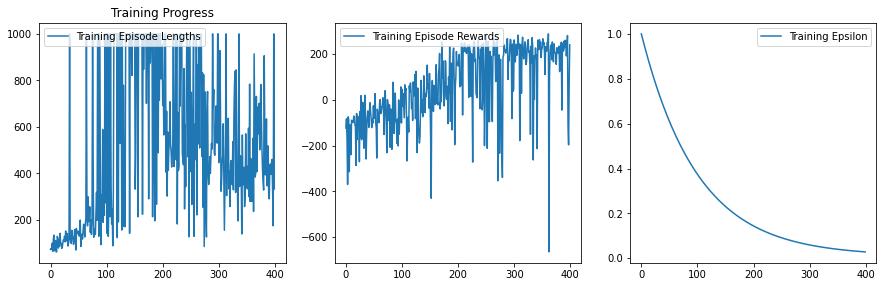

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 15))
plt.subplot(3, 3, 1)
plt.plot(range(TRAIN_EPISODES), episode_lengths, label='Training Episode Lengths')
plt.legend(loc='upper left')
plt.title('Training Progress')

plt.subplot(3, 3, 2)
plt.plot(range(TRAIN_EPISODES), episode_rewards, label='Training Episode Rewards')
plt.legend(loc='upper left')

plt.subplot(3, 3, 3)
plt.plot(range(TRAIN_EPISODES), [ get_epsilon(episode) for episode in range(TRAIN_EPISODES) ], label='Training Epsilon')
plt.legend(loc='upper right')
plt.show()

In [28]:
test_episode_lengths = []
test_episode_rewards = []

for episode in range(TEST_EPISODES):
    total_test_rewards = 0
    steps = 0
    observation = env.reset()
    done = False
    while not done:
        steps += 1
        if False:
            env.render()

        encoded_observation = observation.reshape([1, observation.shape[0]])
        predicted = model.predict(encoded_observation).flatten()
        action = np.argmax(predicted)
        new_observation, reward, done, info = env.step(action)
        
        observation = new_observation
        total_test_rewards += reward

        if done:
            print('Total test rewards: {} after n steps = {} with final reward = {}'.format(total_test_rewards, episode, reward))
            break

    test_episode_lengths.append(steps)
    test_episode_rewards.append(total_test_rewards)
env.close()

Total test rewards: 231.25815948943995 after n steps = 0 with final reward = 100
Total test rewards: -272.14247716497107 after n steps = 1 with final reward = -100
Total test rewards: -341.15339563165924 after n steps = 2 with final reward = -100
Total test rewards: -407.17803822097306 after n steps = 3 with final reward = -3.3768546584637305
Total test rewards: 239.9834801474812 after n steps = 4 with final reward = 100


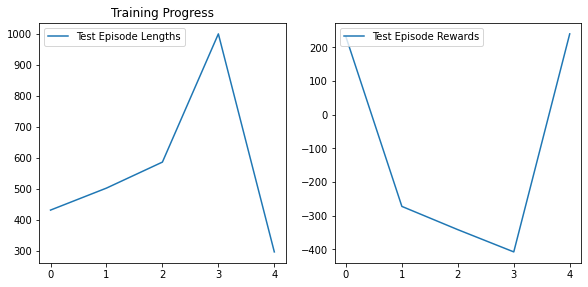

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 15))
plt.subplot(3, 3, 1)
plt.plot(range(TEST_EPISODES), test_episode_lengths, label='Test Episode Lengths')
plt.legend(loc='upper left')
plt.title('Training Progress')

plt.subplot(3, 3, 2)
plt.plot(range(TEST_EPISODES), test_episode_rewards, label='Test Episode Rewards')
plt.legend(loc='upper left')
plt.show()

In [24]:
model.save('lunar_lander')

INFO:tensorflow:Assets written to: lunar_lander/assets
